In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')
train_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.csv')
test_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.csv')
train_h5_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.h5')
test_h5_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.h5')
sys.path.append(base_dir)

from src.tools.window_shifter import WindowShifter
from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

In [2]:
class NILMDataset(Dataset):
    def __init__(self, data_dir, key, transform = None):
        self.data_dir = data_dir
        self.transform = transform
        self.key = key
        with pd.HDFStore(self.data_dir, mode = 'r') as store:
            storer = store.get_storer(key = self.key)
            self.total_lines = storer.nrows
    def __len__(self):
        return self.total_lines
    def __getitem__(self, idx):
        with pd.HDFStore(self.data_dir, mode = 'r') as store:
            sample = store.select(key = self.key, start = idx, stop = idx + 1)
        data = sample.iloc[:,:-9].values.astype(np.float32)
        label = sample.iloc[:,-9:].values.astype(np.float32)
        data = torch.tensor(data, dtype = torch.float32)
        label = torch.tensor(label, dtype = torch.float32)
        if self.transform:
            data = self.transform(data)
        return data, label
        

In [3]:
with pd.HDFStore(train_h5_dir, mode = 'r') as store:
            sample = store.select(key = 'train_house2', start = 0, stop = 1)
data = sample.iloc[:,:-9].values.astype(np.float32)
label = sample.iloc[:,-9:].values.astype(np.float32)
output = torch.tensor(data, requires_grad = False)

In [4]:
output.permute(1,0)

tensor([[ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 88.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 86.],
        [ 85.],
        [ 85.],
        

In [5]:
train_dataset = NILMDataset(train_h5_dir, 'train_house2')
test_dataset = NILMDataset(test_h5_dir, 'test_house2')

In [6]:
batch_size = 256
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 12)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False, num_workers = 12)

In [7]:
if __name__ == '__main__':
    test = next(iter(train_loader))

RuntimeError: DataLoader worker (pid(s) 4400, 17712, 20284, 20724, 20448, 22468, 25080, 2412, 25756, 4172, 18668, 23400) exited unexpectedly

In [ ]:
test[0].shape

torch.Size([256, 1, 300])

In [ ]:
test[1].shape

torch.Size([256, 1, 9])

In [ ]:
len(train_loader)

10287

# Architecture: Encoder ###
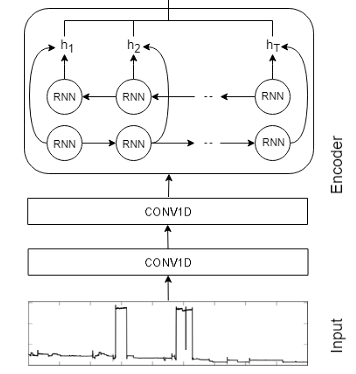

# Attention + Decoder ###
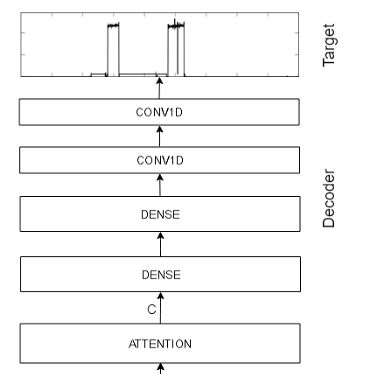

# Chú ý ###
Trong paper đang là kiến trúc s2s nhưng kiến trúc này có vấn đề chính là nó hoạt động giống nlp, yêu cầu 1 chuỗi đầu vào và đưa ra 1 chuỗi đầu ra vấn đề là nếu như có 2 chuỗi overlap với nhau thì kết quả công suất dự đoán của đoạn overlap chưa chắc giống nhau?. Vì thế nên biến đổi kiến trúc của phần decoder đi bằng cách bỏ đi 2 cái conv1d. Sau khi lấy được c từ lớp attention chỉ cần thêm 1 hoặc 2 lớp dense để lấy ra 1 output duy nhất

In [ ]:
in_channels = 1
conv_filters = 32
kernel_size = 3
enc_conv1 = nn.Conv1d(in_channels, conv_filters, kernel_size, padding=kernel_size//2)
        # 3) Conv1D (F filters, linear)
enc_conv2 = nn.Conv1d(conv_filters, conv_filters, kernel_size, padding=kernel_size//2)
enc_conv1(test[0]).shape

torch.Size([256, 32, 300])

# Chú ý ###
Vì lstm yêu cầu đầu vào theo các bước thời gian nên cần shape là batch, length, channels, tưởng tượng mỗi bước thời gian là 1 điểm dữ liệu (có tất cả channels lớp, 1 điểm dữ liệu là xiên tất cả channels lớp đó)

# Cấu tạo của Attention ###
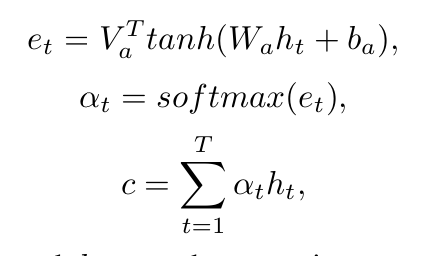

In [ ]:
class S2PwAModel(nn.Module):
    def __init__(self, window_length = 300, in_channels = 1, filter_nums = 32, kernel_size = 3, hidden_dim = 64):
        super().__init__()
        self.window_length = window_length

        # Encoder
        self.conv1 = nn.Conv1d(in_channels, out_channels = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels  = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.bilstm = nn.LSTM(input_size = 32, hidden_size = hidden_dim, batch_first = True, bidirectional = True)
        bilstm_out_dim = hidden_dim * 2 # concat 2 vector của hidden state theo 2 chiều

        # Attention
        self.v_a = nn.Linear(hidden_dim, 1, bias = False)
        self.att_dense = nn.Linear(bilstm_out_dim, hidden_dim)
        self.att_softmax = nn.Softmax(dim = 1)
        
        # thay đổi kiến trúc cũ
        # đầu ra của attention là batch, bilstm_out_dim
        self.fc1 = nn.Linear(bilstm_out_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
    
    def forward(self, x):
        # x sau khi lấy ra từ dataloader đang có dạng batch, channels, length
        x = self.conv1(x)
        x = self.conv2(x)
        # lstm mong đợi đầu vào dạng batch, length, channels
        x = x.permute(0,2,1) 
        h_t, _ = self.bilstm(x) 
        # h_t có dạng batch, length, hidden_dim*2
        energy = nn.Tanh()(self.att_dense(h_t)) # batch, length, hidden_dim
        score = self.v_a(energy) # batch, length, 1 (có thể hiểu là có l hidden state mối hidden state có 1 trọng số riêng để thể hiện sự đóng góp)
        alpha_t = self.att_softmax(score) # batch, length, 1
        c = (h_t * alpha_t).sum(dim = 1) # batch, hidden_dim * 2
        x = self.fc1(c) # batch, 64
        x = self.relu(x) 
        x = self.fc2(x) # batch, 1
        return x

In [ ]:
test_model = S2PwAModel()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Tính Mean và Std của Dataset

In [ ]:
df = pd.read_csv(data_dir)
app_cols = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
invalid_mask_train = df['Aggregate'] <= df[app_cols].sum(axis=1)
df.loc[invalid_mask_train, app_cols] = np.nan
df.loc[invalid_mask_train, 'Aggregate'] = np.nan
df[app_cols] = df[app_cols].ffill()
df[app_cols] = df[app_cols].fillna(0)
df['Aggregate'] = df['Aggregate'].ffill()
df['Aggregate'] = df['Aggregate'].fillna(0)
df_time_to_date = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')
df['dom'] = df_time_to_date.dt.day

In [ ]:
train = df[((df['dom']-1)//7+1)%2==0]

In [ ]:
train_mean = train['Aggregate'].mean()
train_std = train['Aggregate'].std()

In [ ]:
train_mean, train_std

(np.float64(494.62987145211497), np.float64(1088.939294395772))

In [ ]:
df['Aggregate'].mean

<bound method Series.mean of 0          695.0
1          694.0
2          694.0
3          702.0
4          700.0
           ...  
5733521    315.0
5733522    333.0
5733523    313.0
5733524    316.0
5733525    383.0
Name: Aggregate, Length: 5733526, dtype: float64>

# Test model cho app1 trước ###

In [ ]:
model_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1.pth')

In [ ]:
model_app1 = S2PwAModel().to(device)
model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_app1.parameters(), lr = 1e-4)

epochs  = 5

for epoch in range(epochs):
    model_app1.train()
    train_loss = 0.0
    for batch_idx, (data, target) in tqdm(enumerate(train_loader)):
        data = (data - train_mean)/train_std
        target = target[:,:,0]
        data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
        optimizer.zero_grad()
        output = model_app1(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        if batch_idx == 499:
            break
    avg_train_loss = train_loss/(batch_idx + 1)
    print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

0it [00:05, ?it/s]


RuntimeError: DataLoader worker (pid(s) 24832, 13988, 12844, 25080) exited unexpectedly

In [ ]:
torch.save(model_app1.state_dict(), model_save_dir)

In [ ]:
model_app1 = S2PwAModel().to(device)
model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
model_app1.eval()
with torch.no_grad():
    for batch_idx, (data, target) in tqdm(enumerate(test_loader)):
        if batch_idx == 0:
            test_data = data.to(device)
            test_target = target.to(device)
        else:
            test_data = torch.cat((test_data, data.to(device)))
            test_target = torch.cat((test_target, target.to(device)))
        if batch_idx == 9:
            break
    test_target = test_target[:,:,0]
    test_data = (test_data - train_mean)/train_std
    output = model_app1(test_data)
    

9it [00:12,  1.43s/it]


In [ ]:
ground_truth = test_target.cpu().detach().numpy()
pred = output.cpu().detach().numpy()

In [ ]:
for i in ground_truth:
    print(i)

[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]
[1.]


In [ ]:
for i in pred:
    print(i)

[80.239296]
[80.23542]
[80.23037]
[80.2283]
[80.22659]
[80.22352]
[80.22513]
[80.22661]
[80.22404]
[80.21843]
[80.21383]
[80.210754]
[80.20858]
[80.21234]
[80.2108]
[80.203995]
[80.197365]
[80.195694]
[80.19307]
[80.1929]
[80.19411]
[80.19307]
[80.18995]
[80.184326]
[80.18094]
[80.17853]
[80.17525]
[80.17678]
[80.17937]
[80.17584]
[80.169075]
[80.17137]
[80.176926]
[80.17464]
[80.16671]
[80.16059]
[69.93341]
[66.68133]
[65.43252]
[64.33833]
[63.36952]
[62.891872]
[62.887203]
[62.781445]
[63.66862]
[63.581104]
[63.788105]
[64.13139]
[64.340935]
[64.44011]
[64.467224]
[64.37775]
[64.16881]
[63.89156]
[63.584263]
[63.30086]
[63.15382]
[63.13045]
[63.119415]
[63.107647]
[63.07819]
[63.03204]
[62.97379]
[62.905037]
[62.82428]
[62.73185]
[62.630383]
[62.518604]
[62.401043]
[62.29019]
[62.200603]
[62.143448]
[62.134598]
[62.1846]
[62.279102]
[62.399357]
[62.52506]
[62.635693]
[62.719048]
[62.76414]
[62.76665]
[62.72935]
[62.662228]
[62.57072]
[62.468674]
[61.997456]
[62.14509]
[62.34782]
[62.